# Breast Cancer Disease Prediction Using Machine Learning

## 1. Project Introduction

Breast cancer is one of the most common forms of cancer worldwide, and early identification of malignant cases is important for timely clinical evaluation and treatment.

This project applies supervised machine learning classification techniques to the Breast Cancer Wisconsin dataset. Multiple classification algorithms are trained and evaluated to determine how effectively they can distinguish between malignant and benign cases.

The models evaluated in this project are:

- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest
- XGBoost

The models are compared using accuracy, precision, recall, F1-score, and ROC-AUC. Since this is a healthcare-oriented classification problem, particular attention is given to **recall/sensitivity for malignant cases**, because incorrectly classifying a malignant case as benign represents a false negative.

> **Note:** This project is an educational machine-learning experiment and is not intended for clinical diagnosis or medical decision-making.


## 2. Project Objective

The main objectives of this project are:

1. To explore and understand the Breast Cancer Wisconsin dataset.
2. To preprocess the dataset appropriately for machine learning.
3. To train multiple supervised classification models.
4. To evaluate the models using multiple performance metrics.
5. To compare the models based on their predictive performance.
6. To emphasize malignant-class recall as an important healthcare-oriented metric.
7. To identify a suitable model based on the overall evaluation results.

## 3. Dataset Description

The project uses the Breast Cancer Wisconsin dataset available through Scikit-learn.

The dataset contains:

- **569 samples**
- **30 numerical features**
- **1 target variable**

The features represent measurements computed from digitized images of breast tissue samples.

The target variable contains two classes:

- **0 — Malignant**
- **1 — Benign**

The dataset is used as a binary classification problem where the objective is to predict whether a sample belongs to the malignant or benign class.

## 4. Methodology

The project follows the following machine learning workflow:

1. Dataset loading
2. Data inspection
3. Exploratory Data Analysis (EDA)
4. Feature-target separation
5. Train-test splitting
6. Feature scaling where required
7. Model training
8. Model prediction
9. Performance evaluation
10. Model comparison
11. Feature importance analysis
12. Final model selection
13. Sample prediction

In [ ]:
# ============================================================
# BREAST CANCER DISEASE PREDICTION
# Machine Learning Internship Project
# ============================================================

# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
# ============================================================
# STEP 2: LOAD THE BREAST CANCER DATASET
# ============================================================

# Load the Breast Cancer Wisconsin dataset
data = load_breast_cancer()

# Convert the dataset into a Pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add the target column
df["target"] = data.target

# Display the first 5 rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# Check the shape of the dataset
print("Dataset shape:", df.shape)

# Display column names
print("\nFeatures:")
print(data.feature_names)

# Check the target classes
print("\nTarget classes:")
print(data.target_names)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum().sum())

Dataset shape: (569, 31)

Features:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target classes:
['malignant' 'benign']

Missing values:
0


In [ ]:
# ============================================================
# STEP 3: UNDERSTAND THE TARGET VARIABLE
# ============================================================

# Count the number of samples in each class
print("Target distribution:")
print(df["target"].value_counts())

# Display the class names with their counts
print("\nClass distribution:")
for class_id, class_name in enumerate(data.target_names):
    count = (df["target"] == class_id).sum()
    print(f"{class_id} = {class_name}: {count} samples")

Target distribution:
target
1    357
0    212
Name: count, dtype: int64

Class distribution:
0 = malignant: 212 samples
1 = benign: 357 samples


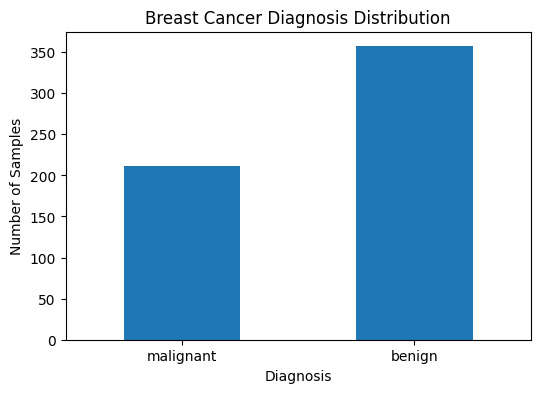

In [ ]:
# Plot the target distribution

plt.figure(figsize=(6, 4))

df["target"].value_counts().sort_index().plot(kind="bar")

plt.xticks(
    ticks=[0, 1],
    labels=data.target_names,
    rotation=0
)

plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.title("Breast Cancer Diagnosis Distribution")

plt.show()

In [ ]:
# Display all feature names

print("Number of features:", len(data.feature_names))

print("\nFeature names:")
for i, feature in enumerate(data.feature_names, start=1):
    print(f"{i}. {feature}")

Number of features: 30

Feature names:
1. mean radius
2. mean texture
3. mean perimeter
4. mean area
5. mean smoothness
6. mean compactness
7. mean concavity
8. mean concave points
9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension


In [ ]:
# Statistical summary of the numerical features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [ ]:
# ============================================================
# STEP 4: EXPLORATORY DATA ANALYSIS
# ============================================================

# Calculate correlation between numerical features
correlation_matrix = df.corr()

# Display the correlation of each feature with the target
target_correlation = correlation_matrix["target"].sort_values(
    ascending=False
)

print("Feature correlation with target:")
print(target_correlation)

Feature correlation with target:
target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.74

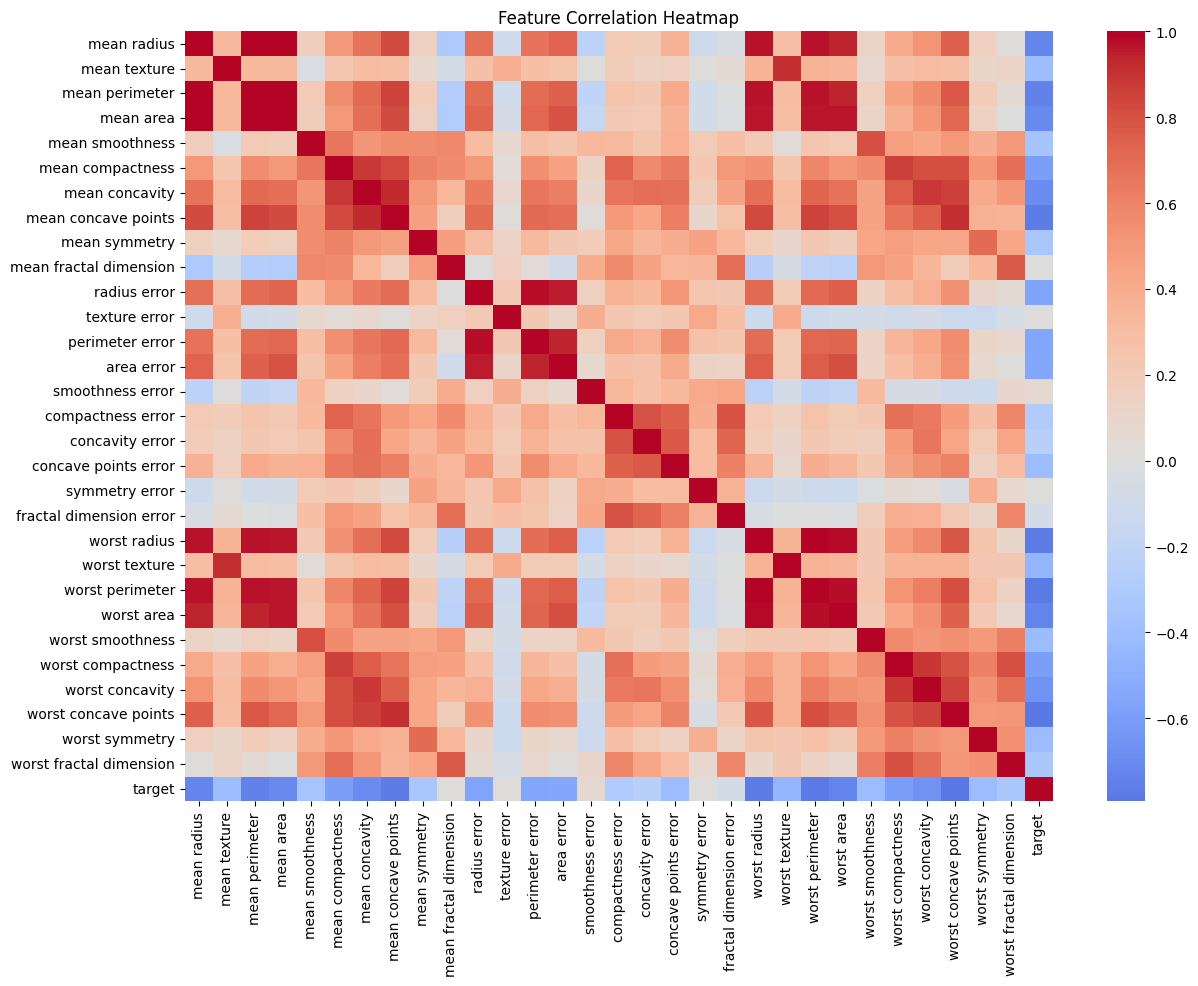

In [ ]:
# Visualize correlations using a heatmap

import seaborn as sns

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

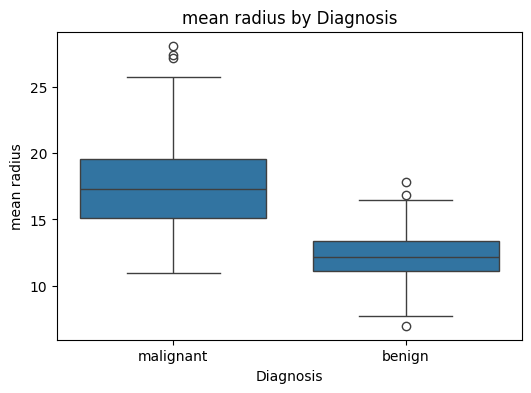

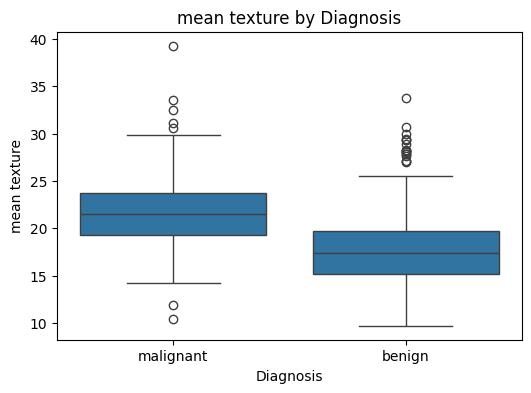

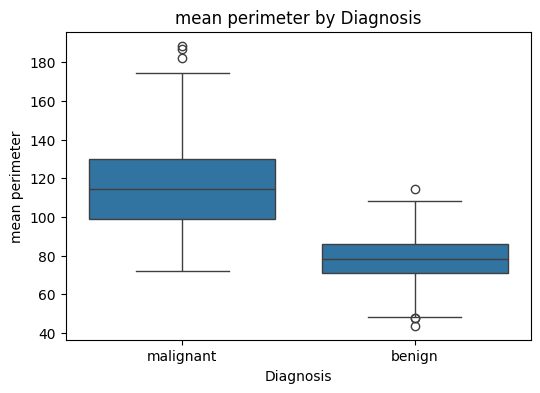

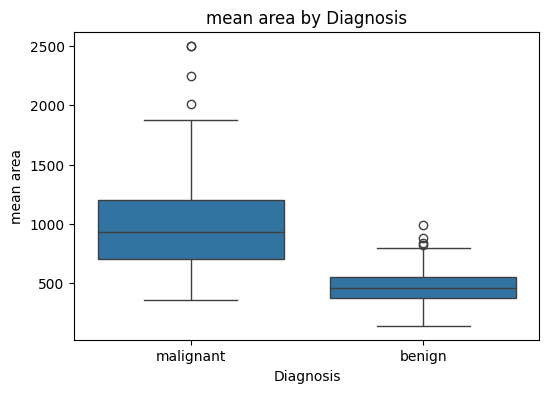

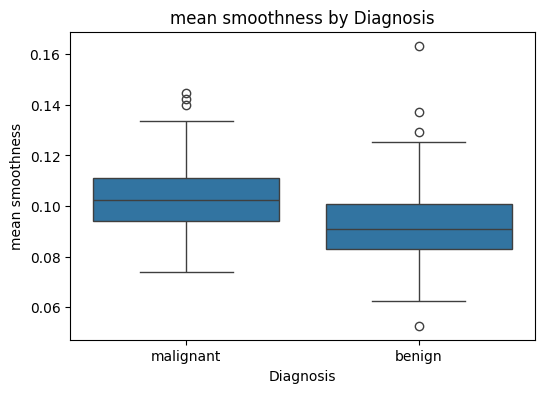

In [ ]:
# Compare selected features across the two diagnosis classes

selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

for feature in selected_features:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=df,
        x="target",
        y=feature
    )

    plt.xticks(
        ticks=[0, 1],
        labels=data.target_names
    )

    plt.xlabel("Diagnosis")
    plt.ylabel(feature)
    plt.title(f"{feature} by Diagnosis")

    plt.show()

In [ ]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Check for missing values in every column

missing_values = df.isnull().sum()

print("Columns containing missing values:")
print(missing_values[missing_values > 0])

Columns containing missing values:
Series([], dtype: int64)


In [ ]:
# ============================================================
# STEP 5: DATA PREPROCESSING
# ============================================================

# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (569, 30)
Target shape: (569,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [ ]:
stratify=y

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


In [ ]:
scaler.fit_transform(X_train)

array([[-1.07200079, -0.6584246 , -1.0880801 , ..., -1.35052668,
        -0.35265805, -0.54138003],
       [ 1.74874285,  0.06650173,  1.75115682, ...,  1.54991557,
         0.19107787, -0.1737386 ],
       [-0.97473376, -0.93112416, -0.99770871, ..., -1.70744192,
        -0.307734  , -1.21303263],
       ...,
       [ 0.39844772,  1.06867262,  0.50751384, ...,  1.53492543,
         0.16164487,  1.23754763],
       [ 0.85331409, -0.0380331 ,  0.9054796 , ...,  2.10455077,
         0.31035897,  0.36249578],
       [-0.91179628, -0.82431683, -0.87666079, ..., -0.51332734,
        -0.50756857,  1.30824791]])

In [ ]:
scaler.transform(X_test)

array([[ 1.56851278,  2.16401585,  1.74286587, ...,  1.20214432,
        -0.14043064,  0.90036171],
       [-0.84027641, -0.5970672 , -0.8741735 , ..., -1.10124064,
        -0.81429139, -0.71323608],
       [-0.07072262,  1.19138742,  0.03202768, ...,  0.57255843,
         1.14997397,  1.86841162],
       ...,
       [ 0.3583966 , -0.44935493,  0.48264098, ...,  1.63386036,
         0.54117564,  1.91191948],
       [-0.41401799,  1.07321761, -0.42314565, ...,  0.06139464,
        -0.1280378 ,  0.64747227],
       [-0.6829327 , -0.69932953, -0.66607058, ..., -0.23615965,
        -0.16211811, -0.20147486]])

In [ ]:
scaler.fit_transform(X_test)

array([[ 1.43544107,  2.41647357,  1.61121976, ...,  1.25138834,
        -0.10401766,  0.99635142],
       [-0.89652843, -0.73660649, -0.93244646, ..., -1.25587981,
        -0.98712601, -0.78992311],
       [-0.1515168 ,  1.30575895, -0.05165217, ...,  0.56607491,
         1.58708406,  2.06799574],
       ...,
       [ 0.2639172 , -0.56792319,  0.38632742, ...,  1.72131756,
         0.78924135,  2.11615953],
       [-0.48386399,  1.17081231, -0.49406394, ...,  0.00966567,
        -0.08777659,  0.7163994 ],
       [-0.74420263, -0.85338723, -0.73017806, ..., -0.31422652,
        -0.13243954, -0.22339654]])

In [ ]:
# ============================================================
# STEP 6: LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using scaled training data
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = logistic_model.predict(X_test_scaled)

# Get probability predictions for ROC-AUC
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Calculate evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_roc_auc:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861
ROC-AUC  : 0.9954


In [ ]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=data.target_names
))

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



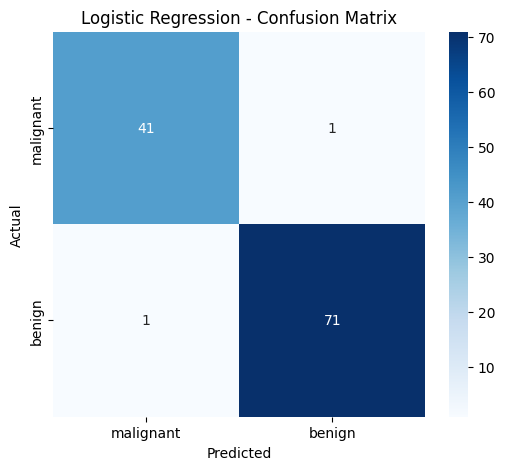

In [ ]:
# Plot confusion matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

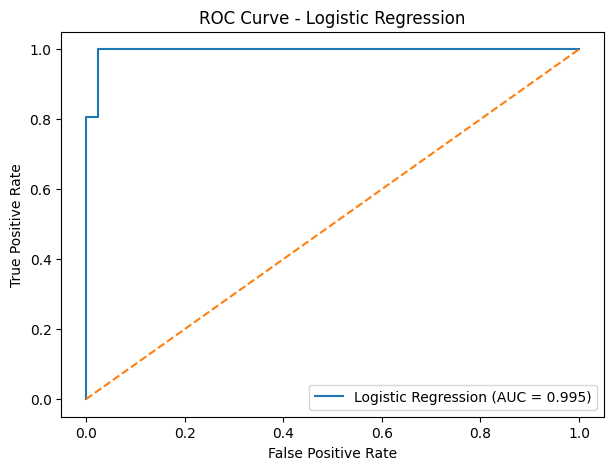

In [ ]:
from sklearn.metrics import roc_curve

# Calculate ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

In [ ]:
# ============================================================
# STEP 7: SUPPORT VECTOR MACHINE (SVM)
# ============================================================

from sklearn.svm import SVC

# Create the SVM model
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

# Train the model using scaled data
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Get probability predictions for ROC-AUC
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print("SVM training completed!")

SVM training completed!


In [ ]:
# Calculate evaluation metrics

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_roc_auc = roc_auc_score(y_test, y_prob_svm)

print("SVM Performance")
print("----------------")
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-Score : {svm_f1:.4f}")
print(f"ROC-AUC  : {svm_roc_auc:.4f}")

SVM Performance
----------------
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861
ROC-AUC  : 0.9950


In [ ]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=data.target_names
))

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



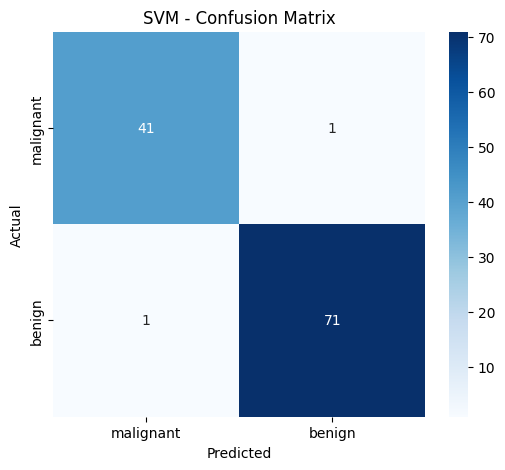

In [ ]:
# Plot SVM confusion matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM - Confusion Matrix")

plt.show()

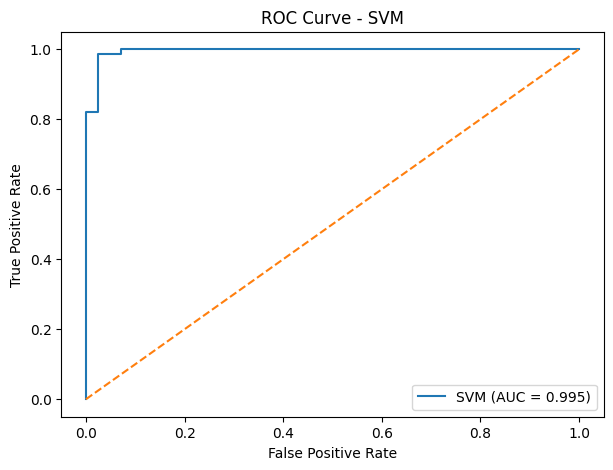

In [ ]:
# Calculate and plot ROC curve

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {svm_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()

plt.show()

In [ ]:
# ============================================================
# STEP 8: RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train using the original (unscaled) features
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Get probability predictions for ROC-AUC
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest training completed!")

Random Forest training completed!


In [ ]:
# Calculate evaluation metrics

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.9474
Precision: 0.9583
Recall   : 0.9583
F1-Score : 0.9583
ROC-AUC  : 0.9937


In [ ]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=data.target_names
))

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



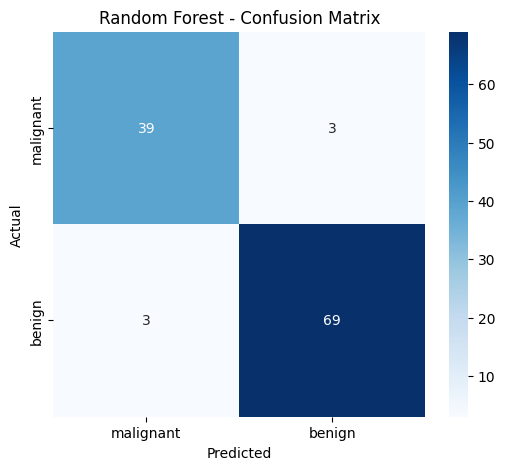

In [ ]:
# Plot Random Forest confusion matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

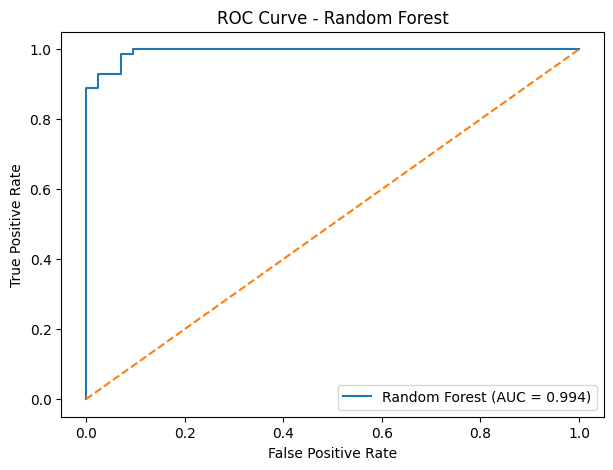

In [ ]:
# Calculate and plot ROC curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

In [ ]:
# Install XGBoost
!pip install -q xgboost

In [ ]:
# ============================================================
# STEP 9: XGBOOST
# ============================================================

from xgboost import XGBClassifier

# Create the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

# Train using the original (unscaled) features
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Get probability predictions for ROC-AUC
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost training completed!")

XGBoost training completed!


In [ ]:
# Calculate evaluation metrics

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Performance")
print("-------------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

XGBoost Performance
-------------------
Accuracy : 0.9474
Precision: 0.9459
Recall   : 0.9722
F1-Score : 0.9589
ROC-AUC  : 0.9927


In [ ]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=data.target_names
))

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



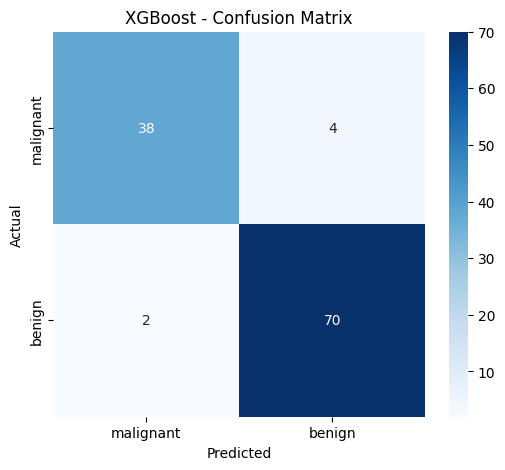

In [ ]:
# Plot XGBoost confusion matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")

plt.show()

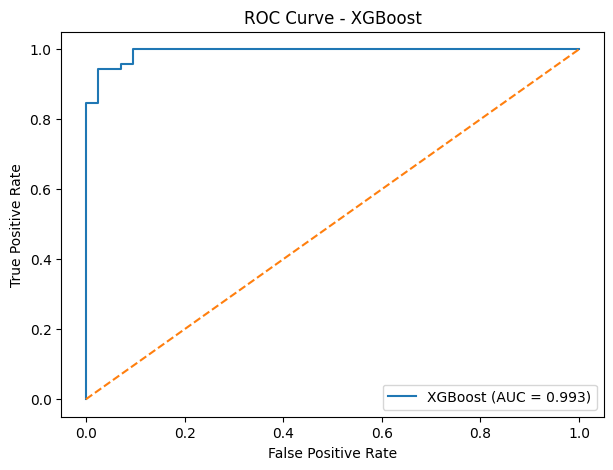

In [ ]:
# Calculate and plot ROC curve

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {xgb_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

In [ ]:
# ============================================================
# STEP 10: MODEL COMPARISON
# ============================================================

from sklearn.metrics import recall_score

# Calculate malignant recall (class 0)
lr_malignant_recall = recall_score(y_test, y_pred_lr, pos_label=0)
svm_malignant_recall = recall_score(y_test, y_pred_svm, pos_label=0)
rf_malignant_recall = recall_score(y_test, y_pred_rf, pos_label=0)
xgb_malignant_recall = recall_score(y_test, y_pred_xgb, pos_label=0)

# Create comparison dataframe
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        svm_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        svm_precision,
        rf_precision,
        xgb_precision
    ],
    "Malignant Recall": [
        lr_malignant_recall,
        svm_malignant_recall,
        rf_malignant_recall,
        xgb_malignant_recall
    ],
    "F1-Score": [
        lr_f1,
        svm_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        lr_roc_auc,
        svm_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

# Display results
results.round(4)

,Model,Accuracy,Precision,Malignant Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9825,0.9861,0.9762,0.9861,0.9954
1,SVM,0.9825,0.9861,0.9762,0.9861,0.9950
2,Random Forest,0.9474,0.9583,0.9286,0.9583,0.9937
3,XGBoost,0.9474,0.9459,0.9048,0.9589,0.9927


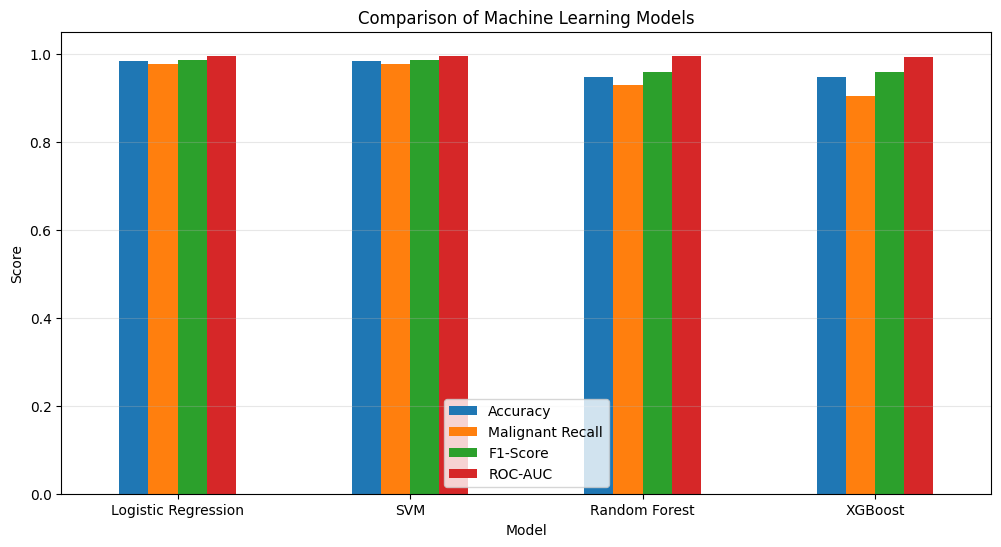

In [ ]:
# Plot model performance comparison

results_plot = results.set_index("Model")

results_plot[
    ["Accuracy", "Malignant Recall", "F1-Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
best_recall_model = results.loc[
    results["Malignant Recall"].idxmax()
]

print("Best model based on malignant recall:")
print(best_recall_model)

Best model based on malignant recall:
Model               Logistic Regression
Accuracy                       0.982456
Precision                      0.986111
Malignant Recall                0.97619
F1-Score                       0.986111
ROC-AUC                         0.99537
Name: 0, dtype: object


In [ ]:
# ============================================================
# STEP 11: DETAILED ANALYSIS OF THE BEST MODEL
# ============================================================

# Confusion matrix for Logistic Regression
cm_best = confusion_matrix(y_test, y_pred_lr)

print("Logistic Regression Confusion Matrix:")
print(cm_best)

print("\nMatrix interpretation:")
print(f"Actual Malignant predicted as Malignant: {cm_best[0, 0]}")
print(f"Actual Malignant predicted as Benign:    {cm_best[0, 1]}")
print(f"Actual Benign predicted as Malignant:    {cm_best[1, 0]}")
print(f"Actual Benign predicted as Benign:       {cm_best[1, 1]}")

Logistic Regression Confusion Matrix:
[[41  1]
 [ 1 71]]

Matrix interpretation:
Actual Malignant predicted as Malignant: 41
Actual Malignant predicted as Benign:    1
Actual Benign predicted as Malignant:    1
Actual Benign predicted as Benign:       71


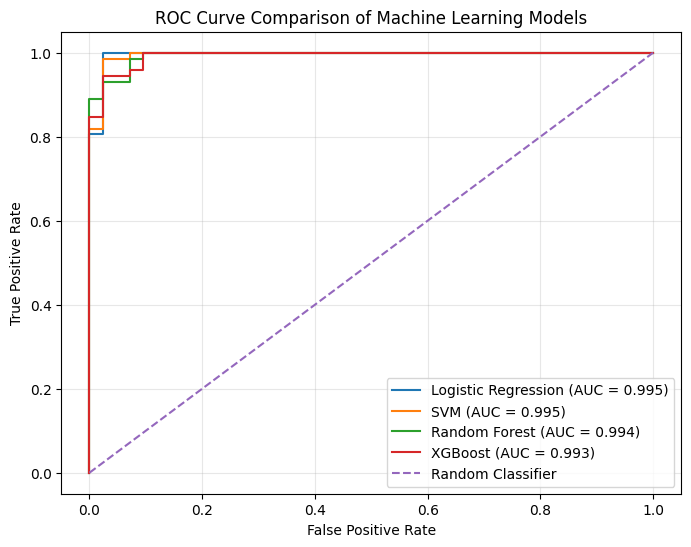

In [ ]:
# ============================================================
# STEP 12: COMBINED ROC CURVE
# ============================================================

plt.figure(figsize=(8, 6))

# Logistic Regression
plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_roc_auc:.3f})"
)

# SVM
plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {svm_roc_auc:.3f})"
)

# Random Forest
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

# XGBoost
plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {xgb_roc_auc:.3f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# STEP 13: FINAL MODEL COMPARISON
# ============================================================

# Calculate malignant-class metrics
lr_malignant_precision = precision_score(
    y_test, y_pred_lr, pos_label=0
)
lr_malignant_f1 = f1_score(
    y_test, y_pred_lr, pos_label=0
)

svm_malignant_precision = precision_score(
    y_test, y_pred_svm, pos_label=0
)
svm_malignant_f1 = f1_score(
    y_test, y_pred_svm, pos_label=0
)

rf_malignant_precision = precision_score(
    y_test, y_pred_rf, pos_label=0
)
rf_malignant_f1 = f1_score(
    y_test, y_pred_rf, pos_label=0
)

xgb_malignant_precision = precision_score(
    y_test, y_pred_xgb, pos_label=0
)
xgb_malignant_f1 = f1_score(
    y_test, y_pred_xgb, pos_label=0
)

# Create final comparison table
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        lr_accuracy,
        svm_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Malignant Precision": [
        lr_malignant_precision,
        svm_malignant_precision,
        rf_malignant_precision,
        xgb_malignant_precision
    ],

    "Malignant Recall": [
        lr_malignant_recall,
        svm_malignant_recall,
        rf_malignant_recall,
        xgb_malignant_recall
    ],

    "Malignant F1": [
        lr_malignant_f1,
        svm_malignant_f1,
        rf_malignant_f1,
        xgb_malignant_f1
    ],

    "ROC-AUC": [
        lr_roc_auc,
        svm_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

# Display results
final_results.round(4)

,Model,Accuracy,Malignant Precision,Malignant Recall,Malignant F1,ROC-AUC
0,Logistic Regression,0.9825,0.9762,0.9762,0.9762,0.9954
1,SVM,0.9825,0.9762,0.9762,0.9762,0.9950
2,Random Forest,0.9474,0.9286,0.9286,0.9286,0.9937
3,XGBoost,0.9474,0.9500,0.9048,0.9268,0.9927


In [ ]:
# Convert metric values to percentages for easier interpretation

percentage_results = final_results.copy()

metric_columns = [
    "Accuracy",
    "Malignant Precision",
    "Malignant Recall",
    "Malignant F1",
    "ROC-AUC"
]

percentage_results[metric_columns] = (
    percentage_results[metric_columns] * 100
).round(2)

percentage_results

,Model,Accuracy,Malignant Precision,Malignant Recall,Malignant F1,ROC-AUC
0,Logistic Regression,98.25,97.62,97.62,97.62,99.54
1,SVM,98.25,97.62,97.62,97.62,99.50
2,Random Forest,94.74,92.86,92.86,92.86,99.37
3,XGBoost,94.74,95.00,90.48,92.68,99.27


In [ ]:
# Identify the model with the highest malignant recall

best_model_name = final_results.loc[
    final_results["Malignant Recall"].idxmax(),
    "Model"
]

best_recall_value = final_results["Malignant Recall"].max()

print(f"Best model based on malignant recall: {best_model_name}")
print(f"Malignant recall: {best_recall_value:.4f}")

Best model based on malignant recall: Logistic Regression
Malignant recall: 0.9762


In [ ]:
# ============================================================
# STEP 14: FEATURE IMPORTANCE
# ============================================================

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 features
feature_importance.head(10)

,Feature,Importance
22,worst perimeter,0.143257
23,worst area,0.130836
27,worst concave points,0.106208
7,mean concave points,0.096277
20,worst radius,0.082035
6,mean concavity,0.052928
2,mean perimeter,0.048060
0,mean radius,0.045953
3,mean area,0.042868
26,worst concavity,0.042752


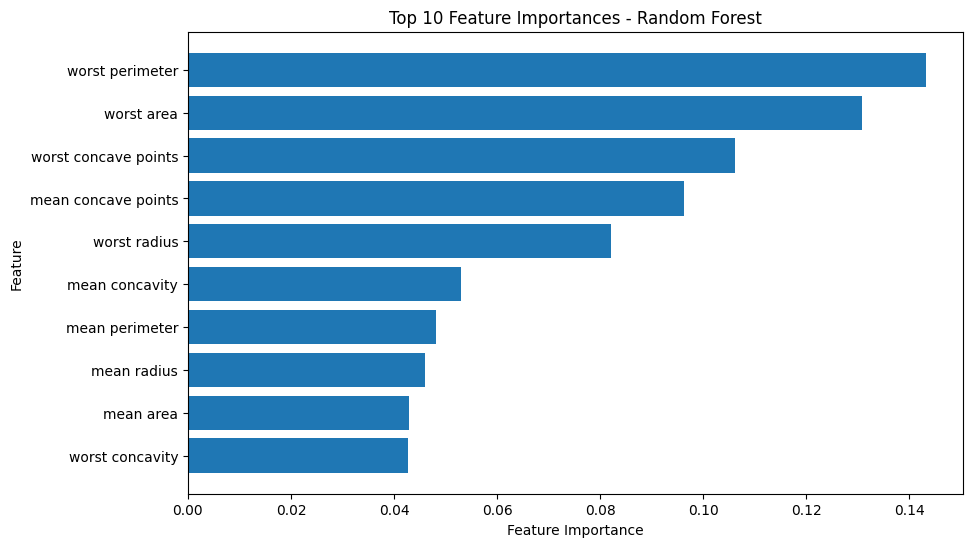

In [ ]:
# Plot top 10 most important features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")

plt.show()

In [ ]:
# ============================================================
# LOGISTIC REGRESSION FEATURE COEFFICIENTS
# ============================================================

lr_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

# Calculate absolute coefficient magnitude
lr_coefficients["Absolute Coefficient"] = (
    lr_coefficients["Coefficient"].abs()
)

# Sort by magnitude
lr_coefficients = lr_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

lr_coefficients.head(10)

,Feature,Coefficient,Absolute Coefficient
21,worst texture,-1.255088,1.255088
10,radius error,-1.082965,1.082965
27,worst concave points,-0.953686,0.953686
23,worst area,-0.947756,0.947756
20,worst radius,-0.947616,0.947616
28,worst symmetry,-0.939181,0.939181
13,area error,-0.929104,0.929104
26,worst concavity,-0.823151,0.823151
22,worst perimeter,-0.763220,0.763220
24,worst smoothness,-0.746625,0.746625


In [ ]:
# ============================================================
# STEP 15: FINAL MODEL SELECTION
# ============================================================

# Rank models primarily by malignant recall
model_ranking = final_results.sort_values(
    by="Malignant Recall",
    ascending=False
).reset_index(drop=True)

print("Models ranked by malignant recall:")
display(model_ranking)

Models ranked by malignant recall:


,Model,Accuracy,Malignant Precision,Malignant Recall,Malignant F1,ROC-AUC
0,Logistic Regression,0.982456,0.976190,0.976190,0.976190,0.995370
1,SVM,0.982456,0.976190,0.976190,0.976190,0.995040
2,Random Forest,0.947368,0.928571,0.928571,0.928571,0.993717
3,XGBoost,0.947368,0.950000,0.904762,0.926829,0.992725


In [ ]:
# ============================================================
# STEP 15.1: SAVE THE FINAL MODEL
# ============================================================

import joblib

# Save the Logistic Regression model
joblib.dump(logistic_model, "breast_cancer_logistic_model.pkl")

# Save the scaler as well
joblib.dump(scaler, "breast_cancer_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [ ]:
# ============================================================
# STEP 16: SAMPLE PATIENT PREDICTION
# ============================================================

# Select one patient from the test set
sample_patient = X_test.iloc[[0]]

# Get the actual diagnosis
actual_class = y_test.iloc[0]

# Scale the patient data using the same scaler
sample_patient_scaled = scaler.transform(sample_patient)

# Make prediction
prediction = logistic_model.predict(sample_patient_scaled)[0]

# Get prediction probabilities
probabilities = logistic_model.predict_proba(sample_patient_scaled)[0]

# Display results
predicted_diagnosis = data.target_names[prediction]
actual_diagnosis = data.target_names[actual_class]

print("SAMPLE PATIENT PREDICTION")
print("=========================")

print(f"Predicted diagnosis: {predicted_diagnosis}")
print(f"Actual diagnosis:    {actual_diagnosis}")

print("\nPrediction probabilities:")
print(f"Malignant: {probabilities[0] * 100:.2f}%")
print(f"Benign:    {probabilities[1] * 100:.2f}%")

SAMPLE PATIENT PREDICTION
Predicted diagnosis: malignant
Actual diagnosis:    malignant

Prediction probabilities:
Malignant: 100.00%
Benign:    0.00%


## 6. Model Performance Results

Four machine learning classification algorithms were trained and evaluated:

- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest
- XGBoost

The models were evaluated using accuracy, malignant-class precision, malignant-class recall, malignant-class F1-score, and ROC-AUC.

Since the application domain is healthcare, malignant-class recall (sensitivity) was given particular importance. A false negative occurs when an actual malignant case is incorrectly classified as benign.

In [ ]:
# Display final model comparison

display(
    percentage_results.style
    .format({
        "Accuracy": "{:.2f}%",
        "Malignant Precision": "{:.2f}%",
        "Malignant Recall": "{:.2f}%",
        "Malignant F1": "{:.2f}%",
        "ROC-AUC": "{:.2f}%"
    })
)

,Model,Accuracy,Malignant Precision,Malignant Recall,Malignant F1,ROC-AUC
0,Logistic Regression,98.25%,97.62%,97.62%,97.62%,99.54%
1,SVM,98.25%,97.62%,97.62%,97.62%,99.50%
2,Random Forest,94.74%,92.86%,92.86%,92.86%,99.37%
3,XGBoost,94.74%,95.00%,90.48%,92.68%,99.27%


## 7. Best Model Analysis

The final model was selected by considering malignant-class recall along with the other evaluation metrics.

For a healthcare-oriented classification problem, malignant recall is particularly important because the model should minimize the number of malignant cases incorrectly classified as benign.

The selected model should therefore demonstrate strong malignant sensitivity while maintaining good precision, F1-score, and ROC-AUC.

In [ ]:
# ============================================================
# SELECT THE BEST MODEL
# ============================================================

# Rank models by malignant recall
model_ranking = final_results.sort_values(
    by="Malignant Recall",
    ascending=False
).reset_index(drop=True)

# Select the top-ranked model
best_model = model_ranking.iloc[0]

print("Best model based on malignant recall:")
print(best_model["Model"])

Best model based on malignant recall:
Logistic Regression


In [ ]:
display(percentage_results)

,Model,Accuracy,Malignant Precision,Malignant Recall,Malignant F1,ROC-AUC
0,Logistic Regression,98.25,97.62,97.62,97.62,99.54
1,SVM,98.25,97.62,97.62,97.62,99.50
2,Random Forest,94.74,92.86,92.86,92.86,99.37
3,XGBoost,94.74,95.00,90.48,92.68,99.27


In [ ]:
# ============================================================
# STEP 19: FINAL RESULTS VERIFICATION
# ============================================================

# Recalculate malignant-class metrics
model_data = {
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "SVM": (y_pred_svm, y_prob_svm),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "XGBoost": (y_pred_xgb, y_prob_xgb)
}

final_results = []

for model_name, (predictions, probabilities) in model_data.items():

    accuracy = accuracy_score(y_test, predictions)

    malignant_precision = precision_score(
        y_test, predictions, pos_label=0
    )

    malignant_recall = recall_score(
        y_test, predictions, pos_label=0
    )

    malignant_f1 = f1_score(
        y_test, predictions, pos_label=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    final_results.append([
        model_name,
        accuracy,
        malignant_precision,
        malignant_recall,
        malignant_f1,
        roc_auc
    ])

# Convert to DataFrame
final_results = pd.DataFrame(
    final_results,
    columns=[
        "Model",
        "Accuracy",
        "Malignant Precision",
        "Malignant Recall",
        "Malignant F1",
        "ROC-AUC"
    ]
)

# Display results
display(final_results.round(4))

,Model,Accuracy,Malignant Precision,Malignant Recall,Malignant F1,ROC-AUC
0,Logistic Regression,0.9825,0.9762,0.9762,0.9762,0.9954
1,SVM,0.9825,0.9762,0.9762,0.9762,0.9950
2,Random Forest,0.9474,0.9286,0.9286,0.9286,0.9937
3,XGBoost,0.9474,0.9500,0.9048,0.9268,0.9927


In [ ]:
# ============================================================
# SELECT BEST MODEL
# ============================================================

model_ranking = final_results.sort_values(
    by="Malignant Recall",
    ascending=False
).reset_index(drop=True)

best_model = model_ranking.iloc[0]

print("FINAL MODEL SELECTION")
print("=====================")
print(f"Model: {best_model['Model']}")
print(f"Accuracy: {best_model['Accuracy'] * 100:.2f}%")
print(f"Malignant Precision: {best_model['Malignant Precision'] * 100:.2f}%")
print(f"Malignant Recall: {best_model['Malignant Recall'] * 100:.2f}%")
print(f"Malignant F1-Score: {best_model['Malignant F1'] * 100:.2f}%")
print(f"ROC-AUC: {best_model['ROC-AUC'] * 100:.2f}%")

FINAL MODEL SELECTION
Model: Logistic Regression
Accuracy: 98.25%
Malignant Precision: 97.62%
Malignant Recall: 97.62%
Malignant F1-Score: 97.62%
ROC-AUC: 99.54%


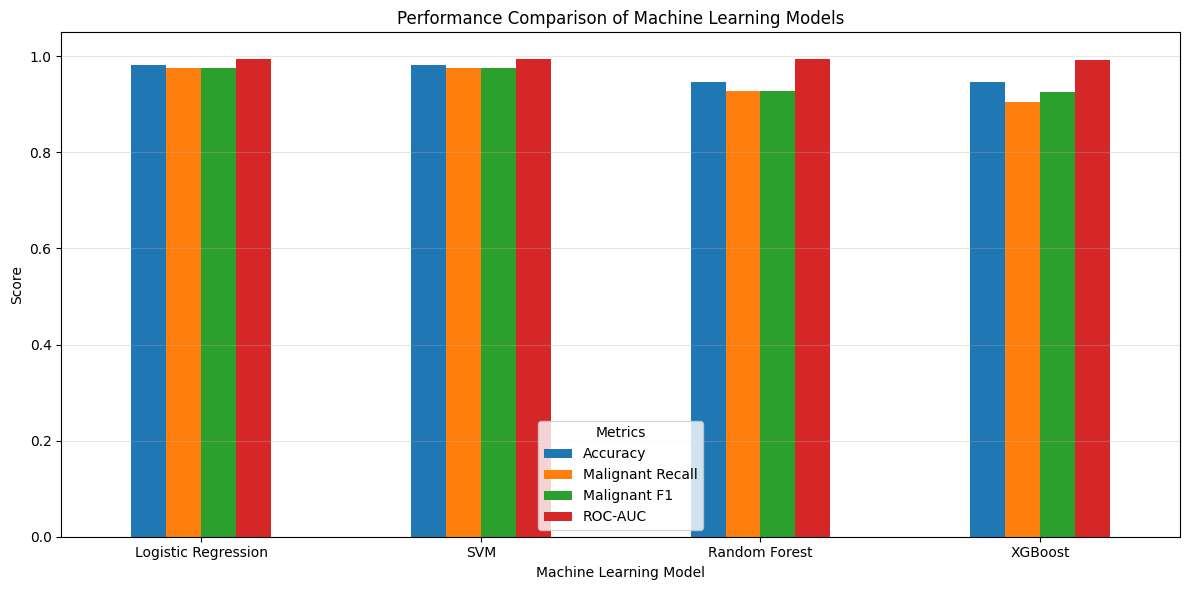

In [ ]:
# ============================================================
# STEP 20: FINAL MODEL PERFORMANCE VISUALIZATION
# ============================================================

# Create a copy for plotting
plot_results = final_results.set_index("Model")

# Select the most important metrics
metrics_to_plot = [
    "Accuracy",
    "Malignant Recall",
    "Malignant F1",
    "ROC-AUC"
]

# Plot comparison
ax = plot_results[metrics_to_plot].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 22: SAVE FINAL MODEL AND SCALER
# ============================================================

import joblib

# Save the trained Logistic Regression model
joblib.dump(
    logistic_model,
    "breast_cancer_logistic_model.pkl"
)

# Save the StandardScaler
joblib.dump(
    scaler,
    "breast_cancer_scaler.pkl"
)

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


In [ ]:
# ============================================================
# VERIFY SAVED MODEL
# ============================================================

# Load the saved model and scaler
loaded_model = joblib.load(
    "breast_cancer_logistic_model.pkl"
)

loaded_scaler = joblib.load(
    "breast_cancer_scaler.pkl"
)

print("Model loaded successfully!")
print("Scaler loaded successfully!")

Model loaded successfully!
Scaler loaded successfully!


In [ ]:
# ============================================================
# TEST LOADED MODEL
# ============================================================

# Take one test sample
sample = X_test.iloc[[0]]

# Scale using the loaded scaler
sample_scaled = loaded_scaler.transform(sample)

# Prediction using the loaded model
loaded_prediction = loaded_model.predict(sample_scaled)[0]

# Prediction probability
loaded_probability = loaded_model.predict_proba(sample_scaled)[0]

print("Prediction from loaded model:")
print("Predicted class:", data.target_names[loaded_prediction])

print("\nPrediction probabilities:")
print(f"Malignant: {loaded_probability[0] * 100:.2f}%")
print(f"Benign:    {loaded_probability[1] * 100:.2f}%")

Prediction from loaded model:
Predicted class: malignant

Prediction probabilities:
Malignant: 100.00%
Benign:    0.00%


In [ ]:
# ============================================================
# STEP 25: FINAL PROJECT SUMMARY
# ============================================================

print("=" * 60)
print("BREAST CANCER CLASSIFICATION - FINAL RESULTS")
print("=" * 60)

display(
    final_results.style.format({
        "Accuracy": "{:.2%}",
        "Malignant Precision": "{:.2%}",
        "Malignant Recall": "{:.2%}",
        "Malignant F1": "{:.2%}",
        "ROC-AUC": "{:.2%}"
    })
)

# Find best model based on malignant recall
best_idx = final_results["Malignant Recall"].idxmax()
best_model = final_results.loc[best_idx]

print("\n" + "=" * 60)
print("SELECTED MODEL")
print("=" * 60)

print(f"Model:              {best_model['Model']}")
print(f"Accuracy:           {best_model['Accuracy']:.2%}")
print(f"Malignant Precision:{best_model['Malignant Precision']:.2%}")
print(f"Malignant Recall:   {best_model['Malignant Recall']:.2%}")
print(f"Malignant F1:       {best_model['Malignant F1']:.2%}")
print(f"ROC-AUC:            {best_model['ROC-AUC']:.2%}")

BREAST CANCER CLASSIFICATION - FINAL RESULTS


,Model,Accuracy,Malignant Precision,Malignant Recall,Malignant F1,ROC-AUC
0,Logistic Regression,98.25%,97.62%,97.62%,97.62%,99.54%
1,SVM,98.25%,97.62%,97.62%,97.62%,99.50%
2,Random Forest,94.74%,92.86%,92.86%,92.86%,99.37%
3,XGBoost,94.74%,95.00%,90.48%,92.68%,99.27%



SELECTED MODEL
Model:              Logistic Regression
Accuracy:           98.25%
Malignant Precision:97.62%
Malignant Recall:   97.62%
Malignant F1:       97.62%
ROC-AUC:            99.54%
